# Lag-CRP Log-Odds Contrasts


Compute log-odds temporal contiguity curves relative to a reference lag.


This template estimates conditional lag-CRP curves, converts them to log-odds, and subtracts a chosen baseline lag so that positive values reflect enrichment over the reference. Update the parameter cell to point at a dataset, filtering logic, and plotting options before executing top-to-bottom or via papermill.


In [5]:
import matplotlib.pyplot as plt
import os
import warnings

from jaxcmr.analyses.log_odds_crp import plot_log_odds_crp
from jaxcmr.helpers import (
    find_project_root,
    generate_trial_mask,
    load_data,
)

warnings.filterwarnings("ignore")

def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()


In [11]:
run_tag = "log_odds_crp"
data_path = "data/LohnasKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = "data['list_type'] == 1"
reference_lag = 10
max_lag = 5
epsilon = 1e-6
size = 3


In [10]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)


Text(0.5, 1.0, 'log_odds_crp')

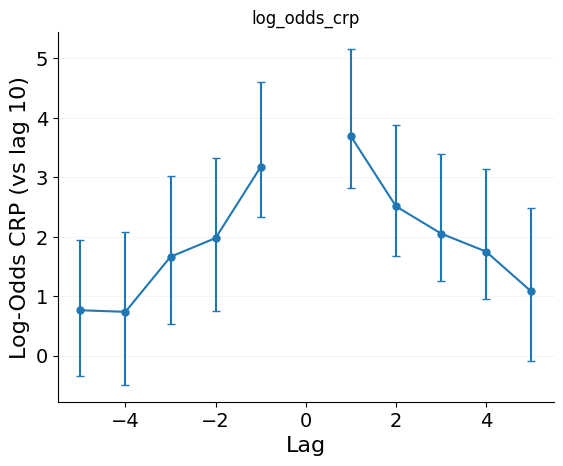

In [ ]:
axis = plot_log_odds_crp(
    data,
    trial_mask,
    max_lag=max_lag,
    reference_lag=reference_lag,
    epsilon=epsilon,
    size=size,
)
axis.set_title(run_tag)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)


## Notes

- Reference lag defines the zero log-odds baseline for every curve.
- Adjust the epsilon clamp if you need to emphasize extreme probabilities.
